## Tools

Models can request to call tools that perform tasks such as fetching data from a database, searching the web, or running code. Tools are pairings of:

1. A schema, including the name of the tool, a description, and/or argument definitions (often a JSON schema) 

2. A function or coroutine to execute.

In [1]:
import os
from dotenv import load_dotenv

load_dotenv()

# Loading Groq API 
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

In [2]:
from langchain.agents import create_agent
from langchain.tools import tool
from langchain_groq import ChatGroq

## Initializing the GROQ with Qwen 3 32B model
model=ChatGroq(model="qwen/qwen3-32b")

#### 1. Binding a tool using create_agent() Function

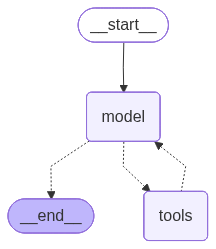

In [3]:
def get_local_time(country_name:str,time:str)->str:
    """Get the local time in a specific country."""
    return f"The local time in {country_name} is {time}."

agent_with_tool_1=create_agent(
    model=model,
    tools=[get_local_time],
    system_prompt="You are a helpful assistant that answers all the questions about anything.",
)

agent_with_tool_1

In [8]:
agent_with_tool_1.invoke({"messages":[{"role": "user", "content": "What is the local time in France?"}]})['messages'][-1].content

'It seems that the tool provided a placeholder response ("now") instead of the actual current time in France. Since I can\'t fetch live data, I recommend checking a reliable clock or time zone service for the current local time in France. Would you like help with any other query?'

#### 2. Binding a tool using bind_tool() Function

In [4]:
## Defining the tool with @tool decorator
@tool
def get_local_time(country_name:str,time:str)->str:
    """Get the local time in a specific country.""" #---> This is the docstring which will be used by the agent to understand the functionality of the tool and how to use it.
    return f"The local time in {country_name} is {time}."

model_with_tool_2=model.bind_tools([get_local_time])

response=model_with_tool_2.invoke("What is the local time in Afghanistan?")

print(response)
for tool_call in response.tool_calls:
    print(f"Tool Name: {tool_call['name']}")
    print(f"Tool Arguments: {tool_call['args']}")

content='' additional_kwargs={'reasoning_content': 'Okay, the user is asking for the local time in Afghanistan. Let me check the tools provided. There\'s a function called get_local_time that requires country_name and time parameters. The country_name is clearly Afghanistan here. But the time parameter is a bit confusing. The function\'s parameters list "time" as a required string. Wait, maybe "time" here refers to the current time in a specific format? Or is it that the function needs the country name and perhaps a time zone? Hmm, the description says it\'s to get the local time, so maybe the "time" parameter is redundant or maybe it\'s a mistake in the function definition. But since the tool requires both, I need to include both. But the user hasn\'t provided a specific time, they just want the current local time. Maybe the "time" parameter is meant to be the current time in UTC or something else. Wait, perhaps the function expects the country name and the current time in another for

### Tool Execution Loop

In [14]:
# 1.Models generates tool calls
messages=[{"role": "user", "content": "What is the local time in Afghanistan?"}]
ai_msg=model_with_tool_2.invoke(messages)
messages.append(ai_msg)

# 2. Execute the tool calls and collect the tool results

for tool_call in ai_msg.tool_calls:
    # Execute the tool call with generated arguments
    tool_result=get_local_time.invoke(tool_call)
    # Append the tool result to the messages list
    messages.append(tool_result)

# 3. Pass the results back to the model to get the final response
final_response=model_with_tool_2.invoke(messages)
print(final_response.text)

## This above code will only works if we are using the 2nd option of tool calling

The local time in Afghanistan is currently **Asia/Kabul** time zone. However, it seems there was a misunderstanding in the response format. To clarify:

- **Time Zone**: Afghanistan operates under the **Asia/Kabul** time zone (UTC+4:30, with no daylight saving time adjustments).
- **Current Local Time**: The actual time depends on the current moment in this time zone. For example, if it’s 10:00 AM UTC, it would be **2:30 PM in Afghanistan**.

Would you like me to provide the exact current time in Afghanistan right now?
